# Chapter 28 Lab — Resting-State and Ecological Designs (Python)

In this lab you will simulate and analyze the two "non-task" paradigms from Chapter 28. We follow a three-part arc:

1. **Resting-state functional connectivity** — simulate multi-ROI resting time series with a known network structure and recover it with a correlation matrix
2. **Inter-subject correlation (ISC)** — simulate a shared naturalistic ("movie") stimulus driving many subjects, and show that ISC is high during the movie but near zero at rest
3. **Confounds** — show how head-motion spikes and vigilance (arousal) drift inflate functional connectivity and can create spurious group differences, and how scrubbing and nuisance regression help

Because everything is simulated with known ground truth, you can see exactly which correlations are "real" network structure and which are artifact — a luxury you never have with real data.

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter environment. It uses only numpy, scipy, pandas, and matplotlib, and every cell runs in seconds. When you are done, return to the [chapter page](../ch28-resting-state-and-ecological-designs.md).

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(precision=2, suppress=True)
rng = np.random.default_rng(28)
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.4.6 | pandas 3.0.5


## Part 1 — Resting-state functional connectivity

During rest there is no task model to fit. Instead, we ask which regions' spontaneous fluctuations rise and fall *together* — functional connectivity. We simulate a 10-minute resting scan (300 volumes, TR = 2 s) for **8 ROIs organized into two networks** (think: a default-mode-like network and a sensorimotor-like network). Each ROI's time series mixes:

- a slow **network-level signal** shared with the other ROIs in its network (weight $w$), and
- slow **ROI-specific fluctuations** (weight $1-w$).

BOLD fluctuations at rest are dominated by low frequencies (< ~0.1 Hz), so we low-pass the white noise by convolving with a smoothing kernel — a crude but effective stand-in for hemodynamic smoothing.

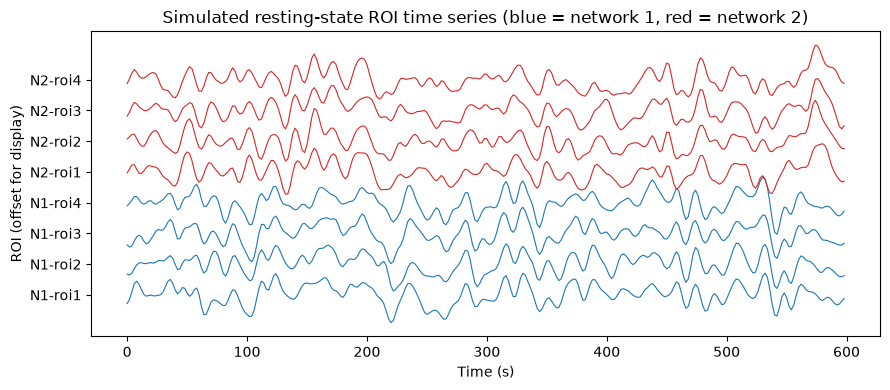

In [2]:
TR = 2.0
n_t = 300                       # 10-minute "scan"
n_roi = 8
network = np.array([0, 0, 0, 0, 1, 1, 1, 1])       # network membership
roi_names = [f"N{net + 1}-roi{i % 4 + 1}" for i, net in enumerate(network)]

kern = np.hanning(9)
kern /= kern.sum()

def smooth_noise(n=n_t):
    """Slow, band-limited fluctuations: low-passed white noise, unit variance."""
    z = np.convolve(rng.standard_normal(n), kern, mode="same")
    return (z - z.mean()) / z.std()

# One slow shared signal per network
net_sig = np.column_stack([smooth_noise(), smooth_noise()])

w = 0.7                                              # network signal weight
Y_rest = np.column_stack([
    w * net_sig[:, network[i]] + (1 - w) * smooth_noise()
    for i in range(n_roi)
])
Y_rest = (Y_rest - Y_rest.mean(0)) / Y_rest.std(0)   # z-score each ROI

t = np.arange(n_t) * TR
fig, ax = plt.subplots(figsize=(9, 4))
for i in range(n_roi):
    color = "tab:blue" if network[i] == 0 else "tab:red"
    ax.plot(t, Y_rest[:, i] + 3 * i, color=color, lw=0.8)
ax.set(xlabel="Time (s)", ylabel="ROI (offset for display)",
       title="Simulated resting-state ROI time series (blue = network 1, red = network 2)")
ax.set_yticks(3 * np.arange(n_roi), roi_names)
plt.tight_layout()

Within each color group the traces visibly rise and fall together — that shared slow fluctuation is what functional connectivity measures. The standard summary is the **ROI × ROI correlation matrix**: with real data you would extract ROI averages from a denoised 4-D image (e.g., CANlab's `extract_roi_averages`, or nilearn's `NiftiLabelsMasker`) and correlate them exactly the same way.

Mean within-network r:  0.85
Mean between-network r: 0.21


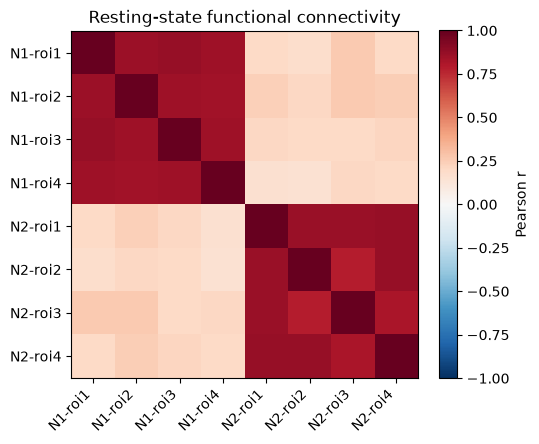

In [3]:
FC_rest = np.corrcoef(Y_rest.T)

def mean_offdiag(FC, mask):
    """Mean correlation over off-diagonal cells selected by a boolean mask."""
    off = ~np.eye(FC.shape[0], dtype=bool)
    return FC[mask & off].mean()

same_net = network[:, None] == network[None, :]
within = mean_offdiag(FC_rest, same_net)
between = mean_offdiag(FC_rest, ~same_net)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(FC_rest, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(n_roi), roi_names, rotation=45, ha="right")
ax.set_yticks(range(n_roi), roi_names)
ax.set_title("Resting-state functional connectivity")
fig.colorbar(im, label="Pearson r")
plt.tight_layout()

print(f"Mean within-network r:  {within:.2f}")
print(f"Mean between-network r: {between:.2f}")

The block structure is unmistakable: strong within-network correlations and much weaker between-network ones. (The between-network correlations are not exactly zero even though the true shared signal is — slow, smooth time series have few effective degrees of freedom, so chance correlations are sizable. Keep this in mind when interpreting real connectivity values.) Data-driven algorithms (clustering, ICA — Chapter 30) find networks by discovering exactly this kind of structure in matrices with thousands of regions instead of 8. Two things to keep in mind:

- **We chose the ground truth.** In real data, whether a correlation reflects neural coupling, shared physiology, or artifact is exactly the hard question (Part 3).
- **Nothing here is time-locked to anything.** If you re-ran this "scan" you would get a *different* time series with the *same* correlation structure. That is why rest supports connectivity analyses but not event-related ones.

## Part 2 — Naturalistic designs and inter-subject correlation

Now the key move of naturalistic imaging: give every subject the **same** rich stimulus. We simulate one stimulus-driven ROI (say, superior temporal cortex during a spoken story) in `n_sub = 10` subjects under two conditions:

- **Movie:** each subject's time series = shared stimulus-driven signal + idiosyncratic fluctuations
- **Rest:** idiosyncratic fluctuations only — nothing shared

**Leave-one-out ISC** correlates each subject's time series with the average of everyone else's. No event onsets, no HRF model — the other brains are the model.

Mean ISC, movie: 0.81
Mean ISC, rest:  -0.03
Movie vs. rest (on Fisher-z ISC): t = 33.5, p = 1.1e-17


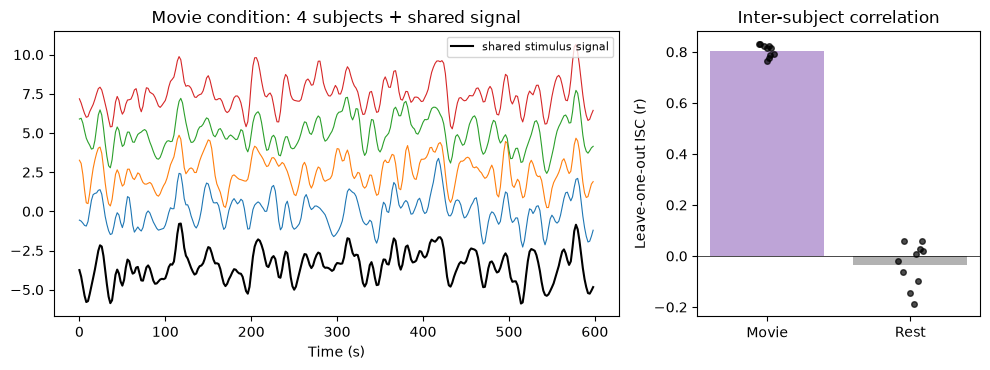

In [4]:
n_sub = 10
movie_sig = smooth_noise()          # the shared stimulus-driven time course
a = 0.6                             # stimulus-driven fraction of the signal

def simulate_group(shared_amp):
    Y = np.column_stack([
        shared_amp * movie_sig + (1 - shared_amp) * smooth_noise()
        for _ in range(n_sub)
    ])
    return (Y - Y.mean(0)) / Y.std(0)

Y_movie = simulate_group(a)         # movie: shared drive + noise
Y_solo = simulate_group(0.0)        # rest: noise only

def isc_loo(Y):
    """Leave-one-out inter-subject correlation for each column (subject)."""
    return np.array([
        np.corrcoef(Y[:, s], np.delete(Y, s, axis=1).mean(axis=1))[0, 1]
        for s in range(Y.shape[1])
    ])

isc_movie = isc_loo(Y_movie)
isc_rest = isc_loo(Y_solo)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), width_ratios=[2, 1])
for s in range(4):                          # show a few subjects
    axes[0].plot(t, Y_movie[:, s] + 2.5 * s, lw=0.8)
axes[0].plot(t, movie_sig - 3.5, "k", lw=1.5, label="shared stimulus signal")
axes[0].set(xlabel="Time (s)", title="Movie condition: 4 subjects + shared signal")
axes[0].legend(loc="upper right", fontsize=8)

for k, (isc_vals, label) in enumerate([(isc_movie, "Movie"), (isc_rest, "Rest")]):
    axes[1].bar(k, isc_vals.mean(), color="tab:purple" if k == 0 else "tab:gray",
                alpha=0.6)
    axes[1].plot(np.full(n_sub, k) + rng.uniform(-0.1, 0.1, n_sub), isc_vals,
                 "ko", ms=4, alpha=0.7)
axes[1].set_xticks([0, 1], ["Movie", "Rest"])
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set(ylabel="Leave-one-out ISC (r)", title="Inter-subject correlation")
plt.tight_layout()

print(f"Mean ISC, movie: {isc_movie.mean():.2f}")
print(f"Mean ISC, rest:  {isc_rest.mean():.2f}")
t_stat, p = stats.ttest_ind(np.arctanh(isc_movie), np.arctanh(isc_rest))
print(f"Movie vs. rest (on Fisher-z ISC): t = {t_stat:.1f}, p = {p:.2g}")

ISC is high wherever — and *only* wherever — activity is driven by the shared stimulus. During rest each brain follows its own trajectory, so ISC hovers around zero. In real naturalistic data, ISC maps typically show strong synchronization in sensory cortices, extending into higher-order regions for engaging narratives — and the *time scale* of shared structure differs across regions, a signature of hierarchical temporal integration.

Note what ISC did **not** require: no event timings, no HRF, no design matrix. But it only detects responses that are *shared and time-locked across people* — idiosyncratic responses (your personal associations to a scene) are invisible to it, even if strongly stimulus-driven.

## Part 3 — Confounds: motion and vigilance

Resting-state connectivity has a dirty secret: several non-neural processes produce *coherent, brain-wide* signals, and correlation-based analyses cannot tell them apart from networks. We look at two of the most important.

### 3a. Motion spikes inflate connectivity

Head motion produces sudden signal changes in *many voxels at once*. A shared artifact, even a brief one, adds a common component to every ROI pair — inflating correlations everywhere, including *between* networks. We add just a handful of motion spikes to the resting data from Part 1 and watch what happens.

       Data  Within-network r  Between-network r
      Clean              0.85               0.21
With spikes              0.89               0.45
   Scrubbed              0.85               0.20


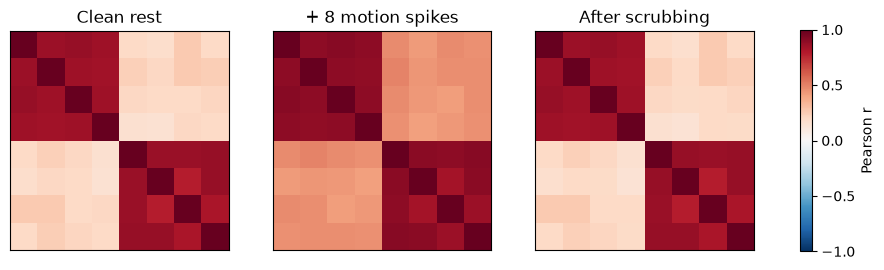

In [5]:
Y_motion = Y_rest.copy()
n_spikes = 8
spike_idx = rng.choice(n_t, n_spikes, replace=False)
# Each spike hits ALL ROIs with the same sign/magnitude pattern (global artifact)
spike_amp = rng.normal(4.0, 1.0, n_spikes)
for idx, amp in zip(spike_idx, spike_amp):
    Y_motion[idx, :] += amp * rng.uniform(0.7, 1.3, n_roi)

FC_motion = np.corrcoef(Y_motion.T)

# "Scrubbing": drop the spike volumes (identified e.g. via framewise displacement)
keep = np.setdiff1d(np.arange(n_t), spike_idx)
FC_scrubbed = np.corrcoef(Y_motion[keep, :].T)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, FC, title in zip(
        axes, [FC_rest, FC_motion, FC_scrubbed],
        ["Clean rest", f"+ {n_spikes} motion spikes", "After scrubbing"]):
    im = ax.imshow(FC, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set(title=title, xticks=[], yticks=[])
fig.colorbar(im, ax=axes, shrink=0.8, label="Pearson r")

rows = []
for FC, label in [(FC_rest, "Clean"), (FC_motion, "With spikes"),
                  (FC_scrubbed, "Scrubbed")]:
    rows.append({"Data": label,
                 "Within-network r": mean_offdiag(FC, same_net),
                 "Between-network r": mean_offdiag(FC, ~same_net)})
print(pd.DataFrame(rows).round(2).to_string(index=False))

Eight bad volumes out of 300 — under 3% of the scan — noticeably inflate the **between-network** correlations, which should be near zero. This is why connectivity pipelines flag outlier volumes (spike/scrubbing regressors, framewise displacement thresholds) and include motion parameters as nuisance covariates; CANlab's `denoise_timeseries_pipeline` and nilearn's `signal.clean` implement exactly these steps. Dropping the spike volumes largely restores the true structure. Crucially, if one *group* moves more than another (children, patients), motion creates spurious group differences in "connectivity."

### 3b. Vigilance drift can masquerade as a group difference

About half of resting participants fall asleep within 10 minutes, and drowsiness is accompanied by large, slow, widespread signal fluctuations. We simulate two groups with **identical** network structure; the "drowsy" group additionally has a global arousal-related fluctuation added to every ROI.

In [6]:
def simulate_rest_subject(global_amp):
    """One subject's 8-ROI resting data; global_amp scales an arousal signal
    added to ALL ROIs (vigilance-related fluctuation)."""
    nets = np.column_stack([smooth_noise(), smooth_noise()])
    arousal = smooth_noise()
    Y = np.column_stack([
        w * nets[:, network[i]] + (1 - w) * smooth_noise()
        + global_amp * arousal
        for i in range(n_roi)
    ])
    return (Y - Y.mean(0)) / Y.std(0)

def mean_fc(Y):
    FC = np.corrcoef(Y.T)
    return mean_offdiag(FC, np.ones_like(same_net))   # mean over all pairs

n_per_group = 12
fc_alert = np.array([mean_fc(simulate_rest_subject(0.0))
                     for _ in range(n_per_group)])
fc_drowsy = np.array([mean_fc(simulate_rest_subject(0.8))
                      for _ in range(n_per_group)])

t_stat, p = stats.ttest_ind(fc_drowsy, fc_alert)
print("Same true networks in both groups; drowsy group has an added global "
      "arousal signal.\n")
print(f"Mean FC, alert group:  {fc_alert.mean():.2f}")
print(f"Mean FC, drowsy group: {fc_drowsy.mean():.2f}")
print(f"Group difference: t({2 * n_per_group - 2}) = {t_stat:.1f}, p = {p:.2g}")

# A simple (if controversial) fix: regress the global mean signal out of each ROI
def mean_fc_gsr(Y):
    g = Y.mean(axis=1, keepdims=True)
    G = np.column_stack([np.ones(n_t), g[:, 0]])
    resid = Y - G @ np.linalg.lstsq(G, Y, rcond=None)[0]
    return mean_offdiag(np.corrcoef(resid.T), np.ones_like(same_net))

fc_drowsy_gsr = np.array([mean_fc_gsr(simulate_rest_subject(0.8))
                          for _ in range(n_per_group)])
print(f"\nDrowsy group after global signal regression: "
      f"mean FC = {fc_drowsy_gsr.mean():.2f}")

Same true networks in both groups; drowsy group has an added global arousal signal.

Mean FC, alert group:  0.36
Mean FC, drowsy group: 0.68
Group difference: t(22) = 18.5, p = 6.8e-15

Drowsy group after global signal regression: mean FC = -0.14


The two groups have *identical* neural network structure, yet the drowsy group shows substantially higher average connectivity — a completely spurious "group difference" driven by arousal. Global signal regression removes much of it (at the cost of shifting the correlation distribution and much methodological debate — Part 6 returns to this). The practical lessons for study design:

- **Monitor wakefulness** (eye tracking, post-scan self-report) and check for group differences in sleepiness and motion before interpreting connectivity differences.
- **Match acquisition conditions** across groups: scan duration, eyes open/closed, time of day.
- Consider **naturalistic paradigms**: an engaging movie constrains mental state, keeps participants awake, and yields more reliable and behavior-predictive connectivity than rest.

## Explore on your own

1. **Scan length and reliability.** Wrap Part 1 in a function of `n_t` and compute the correlation between the estimated `FC` and the "true" FC (from a very long simulation, e.g. `n_t = 5000`) for scans of 3, 6, 9, 13, and 27 minutes. You should reproduce the qualitative result that reliability gains diminish after ~9–13 minutes.
2. **ISC and response idiosyncrasy.** In Part 2, give each subject a random hemodynamic *lag* (shift `movie_sig` by 0–3 volumes per subject) and watch ISC drop even though everyone is stimulus-driven. What does this imply about ISC in regions with variable response timing?
3. **Motion scrubbing tradeoff.** Increase `n_spikes` to 60. How much data can you scrub before the FC estimate itself becomes unstable? (Compare the scrubbed FC to `FC_rest`.)
4. **Group ISC differences.** Simulate two groups whose movie-driven amplitude `a` differs (0.6 vs. 0.3) and test the group difference on Fisher-z ISC values — the naturalistic analog of a group activation comparison.